In [1]:
import matplotlib.pyplot as plt
from mxlpy import Simulator, make_protocol
from mxlmodels import get_lam2026
import pandas as pd

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [3]:
output = pd.read_csv("MATLAB_output.csv", names=["V", "A", "Z", "PV", "PA", "PZ", "QV", "QA", "QZ", "PL", "QL", "PSIId", "alpha_VDE", "P_free", "tau_inv"])
output.index = output.index/10

FileNotFoundError: [Errno 2] No such file or directory: 'MATLAB_output.csv'

In [4]:
protocol = make_protocol([
    (1/60, {"ppfd": 0}),
    (5, {"ppfd": 1}),
    (10, {"ppfd": 0}),
    (5, {"ppfd": 1}),
])


s = Simulator(get_lam2026()).simulate_protocol(protocol, time_points_per_step=100)

res = s.get_result().unwrap_or_err().get_combined()
# res.index = res.index/60


  NEGATIVE TERM: kappa_QA*QA = -0.000000
  NEGATIVE TERM: kappa_QZ*QZ = -0.000000
  NEGATIVE TERM: kappa_QA*QA = -0.000000
  NEGATIVE TERM: kappa_QZ*QZ = -0.000000
  NEGATIVE TERM: kappa_QA*QA = -0.000000
  NEGATIVE TERM: kappa_QZ*QZ = -0.000000
  NEGATIVE TERM: kappa_QA*QA = -0.000000
  NEGATIVE TERM: kappa_QZ*QZ = -0.000000
  NEGATIVE TERM: kappa_QA*QA = -0.000000
  NEGATIVE TERM: kappa_QZ*QZ = -0.000000
  NEGATIVE TERM: kappa_QA*QA = -0.000000
  NEGATIVE TERM: kappa_QZ*QZ = -0.000000
  NEGATIVE TERM: kappa_QA*QA = -0.000000
  NEGATIVE TERM: kappa_QZ*QZ = -0.000000
  NEGATIVE TERM: kappa_QA*QA = -0.000000
  NEGATIVE TERM: kappa_QZ*QZ = -0.000000
  NEGATIVE TERM: kappa_QA*QA = -0.000000
  NEGATIVE TERM: kappa_QZ*QZ = -0.000000
  NEGATIVE TERM: kappa_QA*QA = -0.000000
  NEGATIVE TERM: kappa_QZ*QZ = -0.000000
  NEGATIVE TERM: kappa_QA*QA = -0.000000
  NEGATIVE TERM: kappa_QZ*QZ = -0.000000
  NEGATIVE TERM: kappa_QA*QA = -0.000000
  NEGATIVE TERM: kappa_QZ*QZ = -0.000000
  NEGATIVE TERM:

In [ ]:
for k in ["V", "A", "Z", "PV", "PA", "PZ", "QV", "QA", "QZ", "PL", "QL", "PSIId", "alpha_VDE", "P_free", "tau_inv"]:
    fig, ax = plt.subplots()
    ax.plot(res.index, res[k], label = "mxlpy")
    # ax.plot(output.index, output[k], label = "MATLAB")
    ax.set_title(k)
    ax.legend()
    plt.show()

<Axes: >

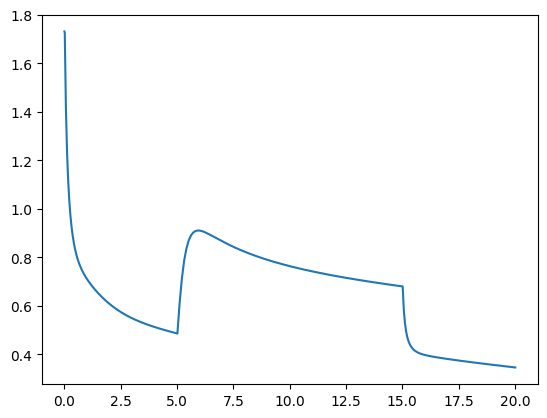

In [7]:
res["tau_Fluo"].plot()